In [1]:
# Importing System
from MDToolkit.IO.read_file import lammps_data_file_to_structured_system

LAMMPS_data_file_path = "/media/jrjoseph/Elements/projects/training/water_box/equilibrated_water_box_spce.out"

system = lammps_data_file_to_structured_system(LAMMPS_data_file_path)

In [2]:
# Plotting functions

import matplotlib.pyplot as plt

def plot_axial_density(
    density_data,
    axis="x",
    show_average=True,
    ax=None
):
    """
    Plot mass density profile.

    Parameters
    ----------
    density_data : dict
        Output of axial_density().
    axis : str
        x, y, or z.
    show_average : bool
        Plot average density as dashed line.
    ax : matplotlib.axes.Axes
        Existing axes. Creates one if None.
    """

    if ax is None:
        fig, ax = plt.subplots()

    ax.plot(
        density_data["bin_centers"],
        density_data["density"],
        label="Density"
    )

    if show_average:
        ax.axhline(
            density_data["average_density"],
            linestyle="--",
            label=f"Average ({density_data['average_density']:.3f} g/cm³)"
        )

    ax.set_xlabel(f"{axis} (Å)")
    ax.set_ylabel("Density (g/cm³)")
    ax.legend()

    return ax

def plot_elemental_number_density(
    density_data,
    axis="x",
    elements=None,
    ax=None
):
    """
    Plot elemental number density profiles.
    """

    if ax is None:
        fig, ax = plt.subplots()

    profiles = density_data["elemental_number_density"]

    if elements is None:
        elements = sorted(profiles.keys())

    for element in elements:
        ax.plot(
            density_data["bin_centers"],
            profiles[element],
            label=element
        )

    ax.set_xlabel(f"{axis} (Å)")
    ax.set_ylabel("Normalized Number Density")
    ax.legend()

    return ax

In [ ]:
from MDToolkit.analysis.density import  axial_density

chosen_axis = "y"

density = axial_density(system, axis=chosen_axis, bins = 250)

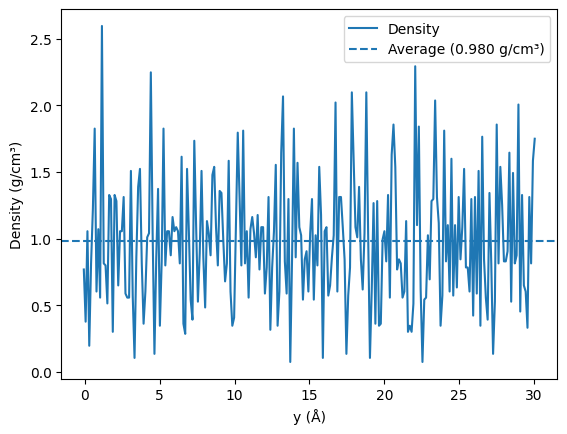

In [15]:
plot_axial_density(density, axis=chosen_axis)
plt.show()

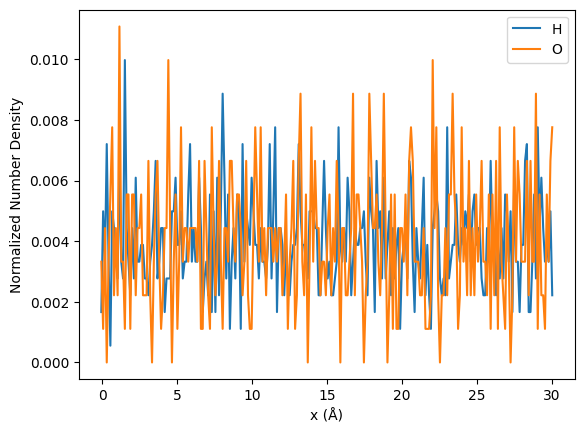

In [16]:
plot_elemental_number_density(density)
plt.show()